In [2]:
import scanpy as sc

In [3]:
adata = sc.read_h5ad('/data2/home/vcivale/scfm-layer-analysis-refactored/data/embeddings/inner_ear_development_tahoe_embeddings.h5ad')

Computing UMAPs for layer 13 (best) and layer 23 (last)...

Processing layer 13...

Processing layer 23...

Generating comparison plots...
Plotting 4 metadata columns...

✓ Saved: layer_comparison_umap.png


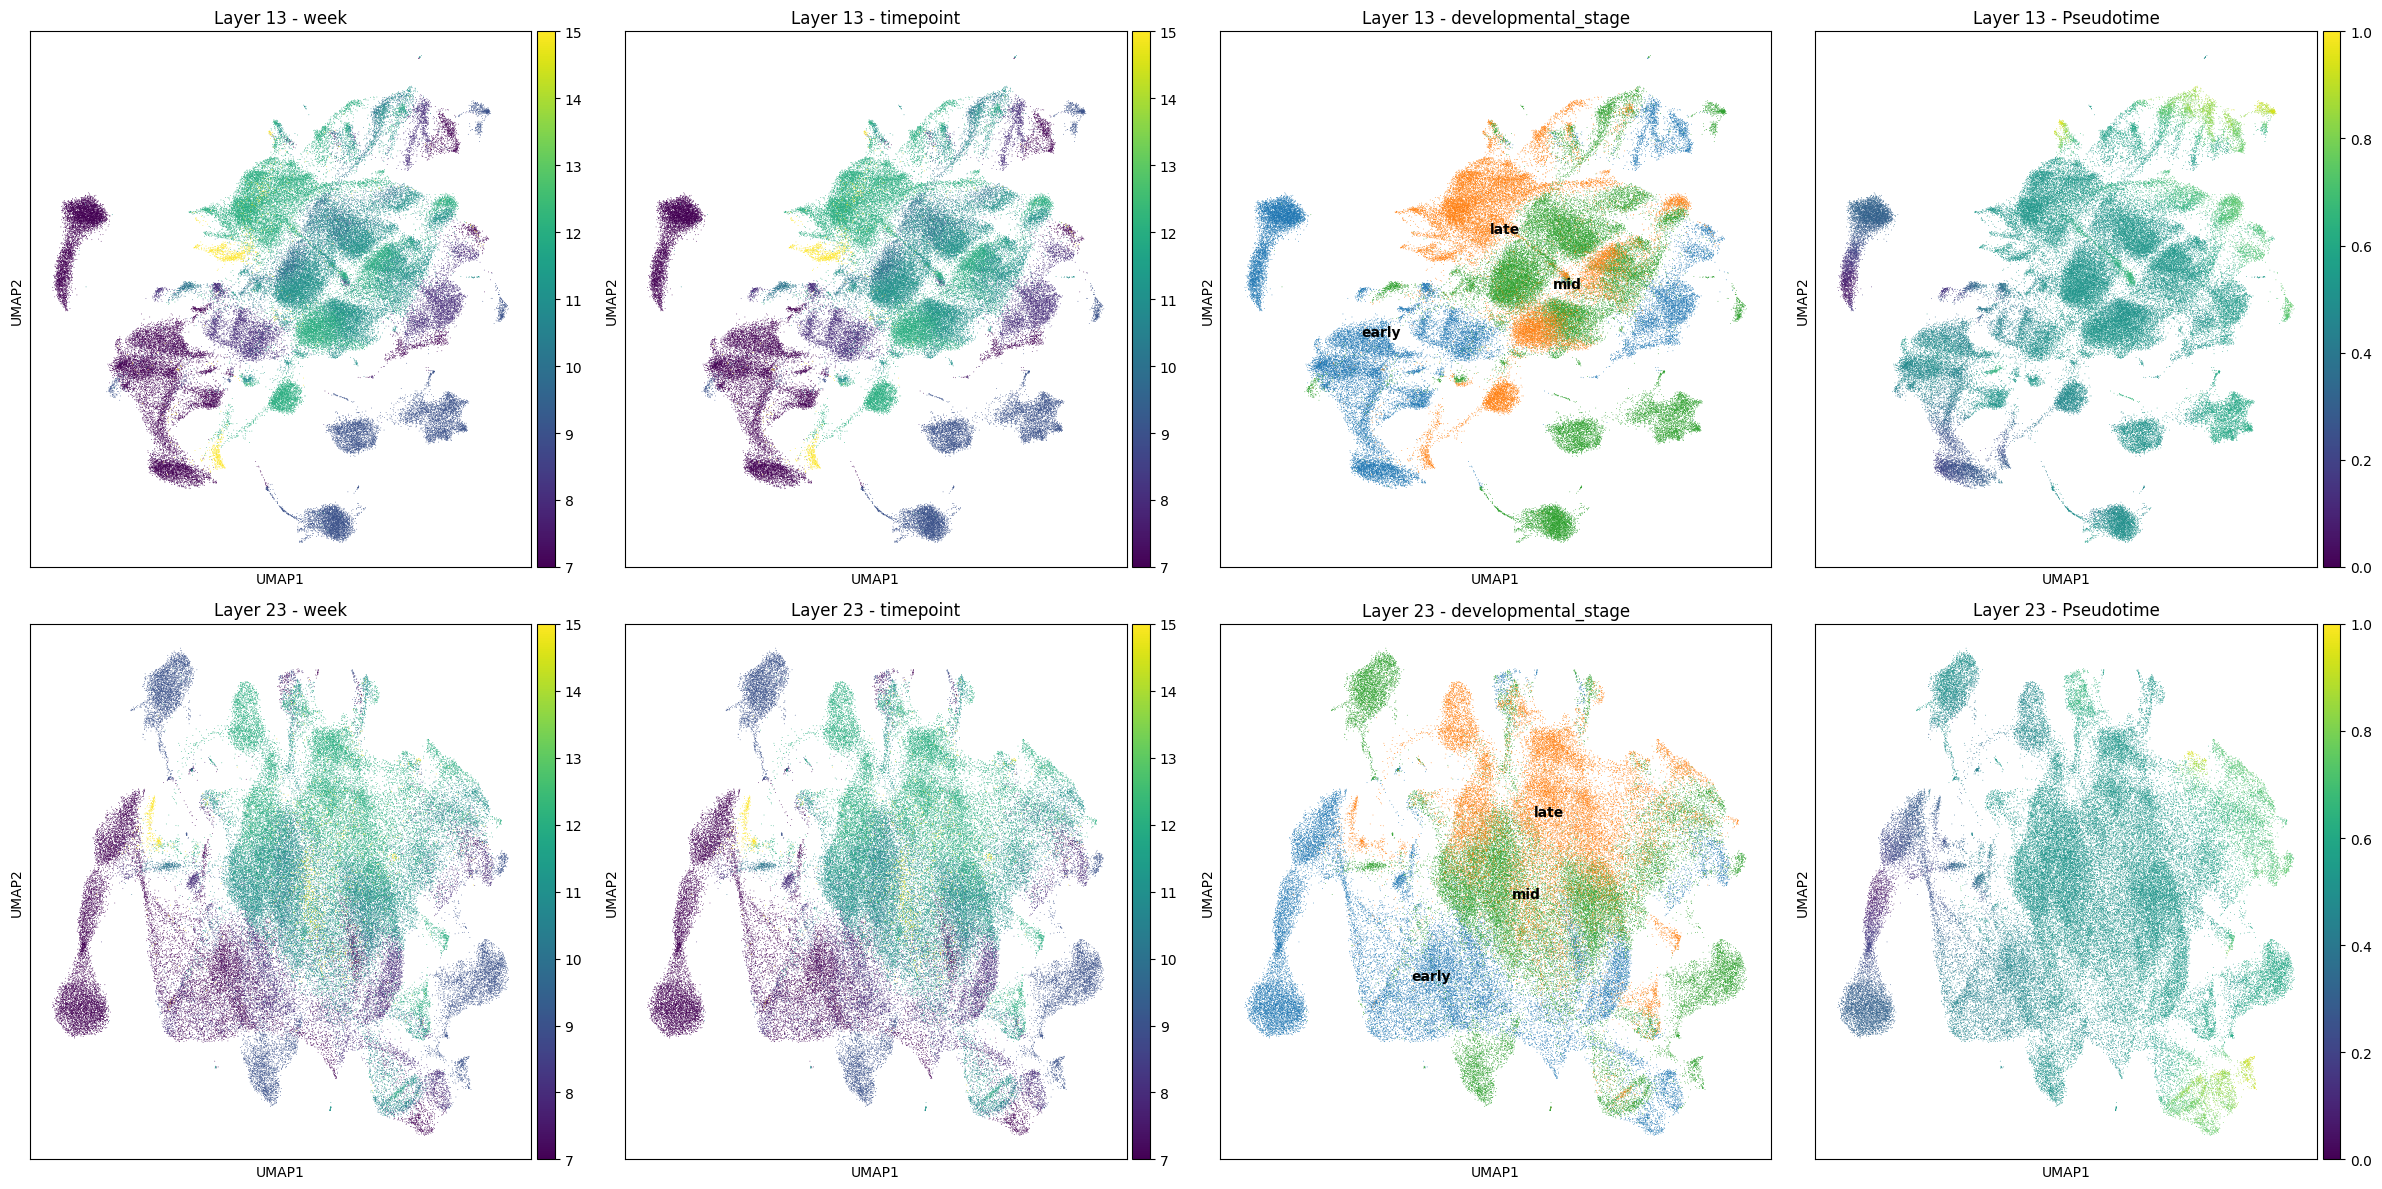

✓ Saved: layer_comparison_simple.png


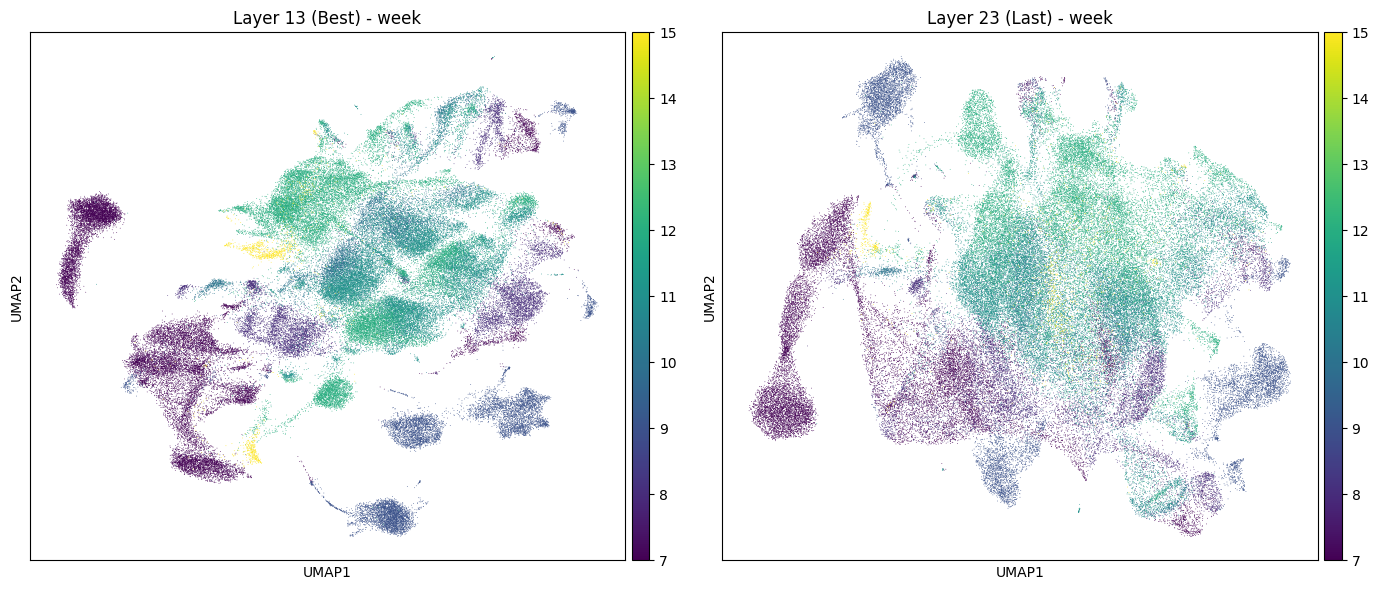


Comparison complete!
Best layer: 13
Last layer: 23
Metadata plotted: week, timepoint, developmental_stage, dpt_pseudotime


In [8]:
"""
Compare UMAP visualizations between best and last layer with multiple annotations.
"""
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np

# Assuming adata is already loaded and has layer embeddings

# Define layers
best_layer = 13
last_layer = 23

print(f"Computing UMAPs for layer {best_layer} (best) and layer {last_layer} (last)...")

# ===== BEST LAYER =====
print(f"\nProcessing layer {best_layer}...")
sc.pp.neighbors(adata, use_rep=f'X_layer_{best_layer}', n_neighbors=15)
sc.tl.umap(adata)
adata.obsm[f'X_umap_layer{best_layer}'] = adata.obsm['X_umap'].copy()

# Compute DPT for best layer (optional, if not already computed)
if 'dpt_pseudotime' not in adata.obs.columns:
    print("  Computing diffusion pseudotime...")
    # Find root cell (earliest timepoint)
    if 'week' in adata.obs.columns:
        min_time = adata.obs['week'].min()
        root_idx = np.where(adata.obs['week'] == min_time)[0][0]
        adata.uns['iroot'] = root_idx
        sc.tl.dpt(adata)
    else:
        print("  Warning: 'week' column not found, skipping DPT")

# ===== LAST LAYER =====
print(f"\nProcessing layer {last_layer}...")
sc.pp.neighbors(adata, use_rep=f'X_layer_{last_layer}', n_neighbors=15)
sc.tl.umap(adata)
adata.obsm[f'X_umap_layer{last_layer}'] = adata.obsm['X_umap'].copy()

# ===== PLOTTING =====
print("\nGenerating comparison plots...")

# Determine available metadata
metadata_to_plot = []
if 'week' in adata.obs.columns:
    metadata_to_plot.append('week')
if 'timepoint' in adata.obs.columns:
    metadata_to_plot.append('timepoint')
if 'developmental_stage' in adata.obs.columns:
    metadata_to_plot.append('developmental_stage')
if 'dpt_pseudotime' in adata.obs.columns:
    metadata_to_plot.append('dpt_pseudotime')

# If no temporal metadata, use what's available
if not metadata_to_plot:
    metadata_to_plot = ['sample', 'batch']  # fallback
    print("Warning: No temporal metadata found, using sample/batch")

n_cols = len(metadata_to_plot)

# Create figure
fig, axes = plt.subplots(2, n_cols, figsize=(6*n_cols, 12))

# Ensure axes is 2D
if n_cols == 1:
    axes = axes.reshape(-1, 1)

print(f"Plotting {n_cols} metadata columns...")

# Row 1: Best layer
adata.obsm['X_umap'] = adata.obsm[f'X_umap_layer{best_layer}']
for i, meta in enumerate(metadata_to_plot):
    if meta == 'dpt_pseudotime':
        sc.pl.umap(adata, color=meta, ax=axes[0, i], show=False, 
                  title=f'Layer {best_layer} - Pseudotime', 
                  cmap='viridis', colorbar_loc='right')
    else:
        sc.pl.umap(adata, color=meta, ax=axes[0, i], show=False,
                  title=f'Layer {best_layer} - {meta}', 
                  legend_loc='on data' if 'stage' in meta else 'right margin')

# Row 2: Last layer
adata.obsm['X_umap'] = adata.obsm[f'X_umap_layer{last_layer}']
for i, meta in enumerate(metadata_to_plot):
    if meta == 'dpt_pseudotime':
        sc.pl.umap(adata, color=meta, ax=axes[1, i], show=False,
                  title=f'Layer {last_layer} - Pseudotime',
                  cmap='viridis', colorbar_loc='right')
    else:
        sc.pl.umap(adata, color=meta, ax=axes[1, i], show=False,
                  title=f'Layer {last_layer} - {meta}',
                  legend_loc='on data' if 'stage' in meta else 'right margin')

plt.tight_layout()
plt.savefig('layer_comparison_umap.png', dpi=300, bbox_inches='tight')
print(f"\n✓ Saved: layer_comparison_umap.png")
plt.show()

# ===== ADDITIONAL: Side-by-side single metadata =====
# Create focused comparison for main temporal variable
if 'week' in adata.obs.columns:
    main_temporal = 'week'
elif 'timepoint' in adata.obs.columns:
    main_temporal = 'timepoint'
else:
    main_temporal = metadata_to_plot[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Best layer
adata.obsm['X_umap'] = adata.obsm[f'X_umap_layer{best_layer}']
sc.pl.umap(adata, color=main_temporal, ax=axes[0], show=False,
          title=f'Layer {best_layer} (Best) - {main_temporal}',
          frameon=True, legend_loc='right margin')

# Last layer
adata.obsm['X_umap'] = adata.obsm[f'X_umap_layer{last_layer}']
sc.pl.umap(adata, color=main_temporal, ax=axes[1], show=False,
          title=f'Layer {last_layer} (Last) - {main_temporal}',
          frameon=True, legend_loc='right margin')

plt.tight_layout()
plt.savefig('layer_comparison_simple.png', dpi=300, bbox_inches='tight')
print(f"✓ Saved: layer_comparison_simple.png")
plt.show()

print("\n" + "="*60)
print("Comparison complete!")
print(f"Best layer: {best_layer}")
print(f"Last layer: {last_layer}")
print(f"Metadata plotted: {', '.join(metadata_to_plot)}")
print("="*60)

In [1]:
import scanpy as sc
adata_pert = sc.read_h5ad("data/embeddings/D4_Rest_undersampled_tahoe.h5ad", backed='r')
adata_pert

AnnData object with n_obs × n_vars = 700000 × 18130 backed at 'data/embeddings/D4_Rest_undersampled_tahoe.h5ad'
    obs: 'lane_id', 'n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'top_guide_UMI_counts', 'guide_id', 'perturbed_gene_name', 'perturbed_gene_id', 'guide_type', 'PuroR', 'guide_group', 'low_quality'
    obsm: 'X_layer_0', 'X_layer_1', 'X_layer_10', 'X_layer_11', 'X_layer_12', 'X_layer_13', 'X_layer_14', 'X_layer_15', 'X_layer_16', 'X_layer_17', 'X_layer_18', 'X_layer_19', 'X_layer_2', 'X_layer_20', 'X_layer_21', 'X_layer_22', 'X_layer_23', 'X_layer_3', 'X_layer_4', 'X_layer_5', 'X_layer_6', 'X_layer_7', 'X_layer_8', 'X_layer_9'

In [6]:
print("Guide types:")
print(adata_pert.obs['guide_type'].value_counts())

print("\nGuide groups:")
print(adata_pert.obs['guide_group'].value_counts())

print("\nSample perturbed_gene_name:")
print(adata_pert.obs['perturbed_gene_name'].value_counts().head(20))

Guide types:
guide_type
targeting        578133
non-targeting     19785
Name: count, dtype: int64

Guide groups:
guide_group
targeting single sgRNA    455406
multi sgRNA               142512
no sgRNA                  102082
Name: count, dtype: int64

Sample perturbed_gene_name:
perturbed_gene_name
NTC         19785
LRP2BP        560
ELOF1         338
NFKBIL1       327
PARP14        273
EDC3          263
CYP20A1       236
SETDB1        234
TANC2         231
RASAL3        221
WDR54         218
ZMAT1         214
PIGB          206
RFX5          201
NR1H2         197
MAPK8         181
ACER2         177
TENT2         177
MAP3K7CL      168
SLC38A7       165
Name: count, dtype: int64


In [4]:
import numpy as np

for key in adata_pert.obsm.keys():
    arr = adata_pert.obsm[key]
    if np.isnan(arr).any():
        print(f"NaN trovati in obsm['{key}']")
    else:
        print(f"Nessun NaN in obsm['{key}']")

Nessun NaN in obsm['X_layer_0']
Nessun NaN in obsm['X_layer_1']
Nessun NaN in obsm['X_layer_10']
Nessun NaN in obsm['X_layer_11']
Nessun NaN in obsm['X_layer_12']
Nessun NaN in obsm['X_layer_13']
Nessun NaN in obsm['X_layer_14']
Nessun NaN in obsm['X_layer_15']
Nessun NaN in obsm['X_layer_16']
Nessun NaN in obsm['X_layer_17']
Nessun NaN in obsm['X_layer_18']
Nessun NaN in obsm['X_layer_19']
Nessun NaN in obsm['X_layer_2']
Nessun NaN in obsm['X_layer_20']
Nessun NaN in obsm['X_layer_21']
Nessun NaN in obsm['X_layer_22']
Nessun NaN in obsm['X_layer_23']
Nessun NaN in obsm['X_layer_3']
Nessun NaN in obsm['X_layer_4']
Nessun NaN in obsm['X_layer_5']
Nessun NaN in obsm['X_layer_6']
Nessun NaN in obsm['X_layer_7']
Nessun NaN in obsm['X_layer_8']
Nessun NaN in obsm['X_layer_9']


In [8]:
import scanpy as sc
adata = sc.read_h5ad('/data/human_cd34_bm_rep1.h5ad')

In [9]:
import mygene

mg = mygene.MyGeneInfo()
gene_symbols = adata.var_names.tolist()

batch_size = 500
results = []

for i in range(0, len(gene_symbols), batch_size):
    batch = gene_symbols[i:i+batch_size]
    res = mg.querymany(batch, scopes='symbol', fields='ensembl.gene', species='human')
    results.extend(res)

# Ora processa results come prima
symbol_to_ensembl = {}
for res in results:
    symbol = res['query']
    if 'ensembl' in res:
        ensembl_data = res['ensembl']
        if isinstance(ensembl_data, list):
            ensembl_id = ensembl_data[0]['gene']
        else:
            ensembl_id = ensembl_data['gene']
        symbol_to_ensembl[symbol] = ensembl_id
    else:
        symbol_to_ensembl[symbol] = None

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


179 input query terms found no hit:	['AAED1', 'ABC13-47656900H15.1', 'AC001226.7', 'AC003973.4', 'AC004069.2', 'AC004156.3', 'AC004257.1
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
52 input query terms found no hit:	['AHSA2', 'AIM1', 'AJ006998.2', 'AJ239322.1', 'AKAP2', 'AL049794.1', 'AL122127.25', 'AL133245.2', 'A
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
4 input query terms found dup hits:	[('ATP6AP1L', 2), ('BACH1-AS1', 2), ('BACH1-IT2', 2), ('BMS1P14', 2)]
52 input query terms found no hit:	['ASNA1', 'ASUN', 'ATP5D', 'ATP5E', 'ATP5EP2', 'ATP5H', 'ATP5I', 'ATP5J', 'ATP5J2', 'ATP5J2-PTCD1', 
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
3 input query terms found dup

In [10]:
import pandas as pd

ensembl_ids = [symbol_to_ensembl.get(g, None) for g in gene_symbols]

# Sostituisco None con stringa vuota
ensembl_ids_str = [str(eid) if eid is not None else '' for eid in ensembl_ids]

adata.var_names = pd.Series(ensembl_ids_str, index=adata.var_names)

# Ora salva senza errori
adata.write_h5ad('data/raw/human_cd34_bm_rep1.h5ad')


In [12]:
adata = sc.read_h5ad('data/embeddings/human_cd34_bm_rep1_tahoe_1b_embeddings.h5ad')

/home/oem/scfm-layer-analysis-refactored/.venv/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [14]:
adata.X = adata.raw.X

In [15]:
adata.write_h5ad('data/raw/human_cd34_bm_rep1_tahoe_1b_embeddings.h5ad')

In [16]:
import numpy as np

# Rendi univoci i nomi dei geni
adata.var_names_make_unique()

# Rimuovi le celle con tutti zeri
adata = adata[adata.X.sum(axis=1) > 0].copy()

In [23]:
adata.write_h5ad('data/raw/human_cd34_bm_rep1_tahoe_1b_embeddings.h5ad')

In [21]:
import numpy as np

# Rimuovi geni con NaN
X = adata.X
if hasattr(X, "toarray"):  # sparse matrix
	X = X.toarray()
X = np.asarray(X, dtype=np.float64)
mask = ~np.isnan(X).any(axis=0)
adata = adata[:, mask].copy()

In [43]:
from datasets import load_dataset
import random

# Carica il dataset in streaming (puoi cambiare split a seconda del bisogno)
ds = load_dataset("Xaira-Therapeutics/X-Atlas-Orion", streaming=True)

# Set guida di interesse (puoi modificarlo o metterlo a None per tutte)
guides_of_interest = {"guideA", "guideB", "guideC"}  # es. metti guide reali, o None

# Funzione per filtrare cellule con pass_guide_filter True e guida di interesse
def filter_cell(cell):
    if not cell.get('pass_guide_filter', False):
        return False
    if guides_of_interest is None:
        return True
    return cell.get('guide_target') in guides_of_interest

# Filtra le cellule
filtered_cells = (cell for cell in ds if filter_cell(cell))

# Prendi un subsample casuale di dimensione max_sample_size (es. 1000)
max_sample_size = 1000
subsample = []
count_filtered = 0

for cell in filtered_cells:
    count_filtered += 1
    if len(subsample) < max_sample_size:
        subsample.append(cell)
    else:
        # Reservoir sampling per mantenere campione casuale tra tutti
        r = random.randint(0, count_filtered - 1)
        if r < max_sample_size:
            subsample[r] = cell

print(f"Totale cellule filtrate: {count_filtered}")
print(f"Dimensione subsample estratto: {len(subsample)}")


/home/oem/scfm-layer-analysis-refactored/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AttributeError: 'str' object has no attribute 'get'

In [28]:
adata_or = sc.read_h5ad('data/raw/human_cd34_bm_rep1.h5ad')

/home/oem/scfm-layer-analysis-refactored/.venv/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [38]:
adata = sc.read_h5ad('data/embeddings/human_cd34_bm_rep1_tahoe_1b_embeddings.h5ad')

/home/oem/scfm-layer-analysis-refactored/.venv/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [3]:
from datasets import load_dataset

ds = load_dataset(
    "Xaira-Therapeutics/X-Atlas-Orion",
    streaming=True
)


/home/oem/scfm-layer-analysis-refactored/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ds

IterableDatasetDict({
    HCT116: IterableDataset({
        features: ['gene_token_id', 'gene_expression', 'cell_barcode', 'sample', 'num_features', 'guide_target', 'gene_target', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'pass_guide_filter'],
        num_shards: 109
    })
    HEK293T: IterableDataset({
        features: ['gene_token_id', 'gene_expression', 'cell_barcode', 'sample', 'num_features', 'guide_target', 'gene_target', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'pass_guide_filter'],
        num_shards: 223
    })
})

In [3]:
hct = load_dataset(
    "Xaira-Therapeutics/X-Atlas-Orion",
    split="HCT116",
    streaming=True
)

from collections import Counter

gene_counter = Counter()
guide_counter = Counter()

for i, cell in enumerate(hct):
    gene_counter[cell["gene_target"]] += 1
    guide_counter[cell["guide_target"]] += 1
    if i > 200_000:
        break


KeyboardInterrupt: 

In [4]:
len(gene_counter), len(guide_counter)


(15952, 18029)

In [ ]:
from collections import Counter

gene_counts = Counter()

for cell in hct:  # streaming
    if cell["pass_guide_filter"]:
        gene_counts[cell["gene_target"]] += 1


In [1]:
from datasets import load_dataset
from collections import Counter

hct = load_dataset(
    "Xaira-Therapeutics/X-Atlas-Orion",
    split="HCT116",
    streaming=True
)

gene_counts = Counter()

for i, cell in enumerate(hct):
    if cell["pass_guide_filter"]:
        gene_counts[cell["gene_target"]] += 1
    if i == 3_000_000:
        break



/home/oem/scfm-layer-analysis-refactored/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


KeyboardInterrupt: 

In [2]:
import numpy as np

counts = np.array(list(gene_counts.values()))

p25, p50, p75 = np.percentile(counts, [25, 50, 75])
p25, p50, p75


(np.float64(17.0), np.float64(30.0), np.float64(48.0))

In [3]:
low, mid, high = [], [], []

for gene, n in gene_counts.items():
    if n <= p25:
        low.append(gene)
    elif n <= p75:
        mid.append(gene)
    else:
        high.append(gene)

len(low), len(mid), len(high)


(4661, 9137, 4422)

In [ ]:
import numpy as np
import pandas as pd
from collections import Counter, defaultdict
from datasets import load_dataset
import anndata
from scipy.sparse import lil_matrix
import random

random.seed(42)
np.random.seed(42)

# --- PARAMETRI ---
N_LOW = 500
N_MID = 1000
N_HIGH = 500

MAX_CELLS_LOW = None   # tutte
MAX_CELLS_MID = 15
MAX_CELLS_HIGH = 20

# --- PASSO 1: Conta cellule per perturbazione (gene_target) ---

print("Counting cells per gene_target...")

hct = load_dataset("Xaira-Therapeutics/X-Atlas-Orion", split="HCT116", streaming=True)

gene_counts = Counter()
for i, cell in enumerate(hct):
    if cell["pass_guide_filter"]:
        gene_counts[cell["gene_target"]] += 1
    if i > 2_000_000:  # early stop per velocità
        break

counts = np.array(list(gene_counts.values()))
p25, p50, p75 = np.percentile(counts, [25, 50, 75])
print(f"Percentili (p25, p50, p75): {p25}, {p50}, {p75}")

# --- PASSO 2: Definisci strati ---

low_genes = [g for g, c in gene_counts.items() if c <= p25]
mid_genes = [g for g, c in gene_counts.items() if p25 < c <= p75]
high_genes = [g for g, c in gene_counts.items() if c > p75]

print(f"Low abundance genes: {len(low_genes)}")
print(f"Mid abundance genes: {len(mid_genes)}")
print(f"High abundance genes: {len(high_genes)}")

# --- PASSO 3: Seleziona random stratificato perturbazioni ---

selected_low = random.sample(low_genes, min(N_LOW, len(low_genes)))
selected_mid = random.sample(mid_genes, min(N_MID, len(mid_genes)))
selected_high = random.sample(high_genes, min(N_HIGH, len(high_genes)))

selected_genes = set(selected_low + selected_mid + selected_high)
print(f"Selected genes total: {len(selected_genes)}")

# --- PASSO 4: Setup max cellule per gene ---

max_cells_per_gene = {}
for g in selected_low:
    max_cells_per_gene[g] = MAX_CELLS_LOW
for g in selected_mid:
    max_cells_per_gene[g] = MAX_CELLS_MID
for g in selected_high:
    max_cells_per_gene[g] = MAX_CELLS_HIGH

# --- PASSO 5: Estrazione dati cellula per cellula ---

print("Extracting cells for selected perturbations...")

ds = load_dataset("Xaira-Therapeutics/X-Atlas-Orion", split="HCT116", streaming=True)

cell_counts = Counter()
cell_data = []
gene_token_set = set()

for cell in ds:
    if not cell["pass_guide_filter"]:
        continue
    gene = cell["gene_target"]
    if gene not in selected_genes:
        continue

    if max_cells_per_gene[gene] is not None and cell_counts[gene] >= max_cells_per_gene[gene]:
        continue

    cell_data.append(cell)
    cell_counts[gene] += 1

print(f"Extracted {len(cell_data)} cells in total.")

# --- PASSO 6: Costruzione matrice espressione sparsa ---

for cell in cell_data:
    gene_token_set.update(cell["gene_token_id"])

gene_token_list = sorted(gene_token_set)
gene_token_to_idx = {g: i for i, g in enumerate(gene_token_list)}

n_cells = len(cell_data)
n_genes = len(gene_token_list)

print(f"Building sparse matrix: {n_cells} cells × {n_genes} genes...")

X = lil_matrix((n_cells, n_genes), dtype=np.float32)

for i, cell in enumerate(cell_data):
    gene_ids = cell["gene_token_id"]
    exprs = cell["gene_expression"]
    for g_id, expr in zip(gene_ids, exprs):
        j = gene_token_to_idx[g_id]
        X[i, j] = expr

# --- PASSO 7: Prepara metadata cellule ---

obs = pd.DataFrame({
    "cell_barcode": [c["cell_barcode"] for c in cell_data],
    "sample": [c["sample"] for c in cell_data],
    "guide_target": [c["guide_target"] for c in cell_data],
    "gene_target": [c["gene_target"] for c in cell_data],
    "n_genes_by_counts": [c["n_genes_by_counts"] for c in cell_data],
    "total_counts": [c["total_counts"] for c in cell_data],
    "total_counts_mt": [c["total_counts_mt"] for c in cell_data],
    "pct_counts_mt": [c["pct_counts_mt"] for c in cell_data],
    "pass_guide_filter": [c["pass_guide_filter"] for c in cell_data],
})

# --- PASSO 8: Carica metadata geni ---

gene_metadata = load_dataset("Xaira-Therapeutics/X-Atlas-Orion", "gene_metadata")
gene_meta_df = pd.DataFrame(gene_metadata)
gene_meta_sub = gene_meta_df[gene_meta_df["gene_token_id"].isin(gene_token_list)].copy()
gene_meta_sub = gene_meta_sub.set_index("gene_token_id").loc[gene_token_list]

# --- PASSO 9: Costruisci AnnData e salva ---

adata = anndata.AnnData(X=X.tocsr(), obs=obs, var=gene_meta_sub)

output_path = "XAtlasOrion_HCT116_subset.h5ad"
print(f"Saving AnnData to {output_path} ...")
adata.write(output_path)
print("Done.")


Counting cells per gene_target...


In [1]:
DEBUG = True
MAX_DEBUG_CELLS = 500


In [4]:
for i, cell in enumerate(ds):
    if not cell["pass_guide_filter"]:
        continue
    gene = cell["gene_target"]
    if gene not in selected_genes:
        continue

    if max_cells_per_gene[gene] is not None and cell_counts[gene] >= max_cells_per_gene[gene]:
        continue

    cell_data.append(cell)
    cell_counts[gene] += 1

    if DEBUG and len(cell_data) >= MAX_DEBUG_CELLS:
        break


TypeError: string indices must be integers

In [ ]:
print("QC CHECKS")
print("Cells:", X.shape[0])
print("Genes:", X.shape[1])
print("obs rows:", obs.shape[0])
print("var rows:", gene_meta_sub.shape[0])

assert X.shape[0] == obs.shape[0]
assert X.shape[1] == gene_meta_sub.shape[0]
assert obs["gene_target"].nunique() <= 2000


In [7]:
gene_metadata = load_dataset(
    "Xaira-Therapeutics/X-Atlas-Orion",
    "gene_metadata"
)

gene_meta_df = gene_metadata["train"].to_pandas()


In [8]:
gene_meta_df.head()

,ensembl_id,gene_name,gene_token_id
0,ENSG00000290825,DDX11L2,0
1,ENSG00000243485,MIR1302-2HG,1
2,ENSG00000237613,FAM138A,2
3,ENSG00000290826,ENSG00000290826,3
4,ENSG00000186092,OR4F5,4


In [10]:
import scanpy as sc
adata = sc.read_h5ad('/data/GSE276896_adata_meta.h5ad')

In [15]:
import mygene
# Prendi i nomi dei geni attuali
genes = adata.var_names.tolist()

# Inizializza mygene query
mg = mygene.MyGeneInfo()

# Query batch per simboli genici (ad esempio specie umano)
query_res = mg.querymany(genes, scopes='symbol', fields='ensembl.gene', species='human')

# Crea dizionario mapping simbolo -> ensembl_id (prendi il primo Ensembl ID se multipli)
symbol2ensembl = {}
for entry in query_res:
    if 'notfound' in entry and entry['notfound']:
        continue
    ensembl_id = None
    if 'ensembl' in entry:
        if isinstance(entry['ensembl'], list):
            ensembl_id = entry['ensembl'][0]['gene']
        else:
            ensembl_id = entry['ensembl']['gene']
    if ensembl_id:
        symbol2ensembl[entry['query']] = ensembl_id

# Mappa i nomi originali in Ensembl
new_var_names = [symbol2ensembl.get(gene, gene) for gene in genes]

# Sostituisci var_names in AnnData
adata.var_names = new_var_names


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


17 input query terms found dup hits:	[('PDCD4-AS1', 2), ('HBD', 2), ('LINC00938', 2), ('TPT1-AS1', 2), ('RPPH1', 2), ('7SK', 10), ('SNORD
404 input query terms found no hit:	['C1orf233', 'RP11-169K16.9', 'UBXN10-AS1', 'C1orf63', 'RP4-728D4.2', 'PPAP2B', 'RP5-1065J22.8', 'RP


In [21]:
import scanpy as sc

# Percorso alla cartella contenente i file barcodes.tsv.gz, features.tsv.gz e matrix.mtx.gz
data_dir = "/data/GSE297393/GSM8989955_UT"  # esempio, cambia secondo la directory giusta

# Carica la matrice 10x
adata = sc.read_10x_mtx(data_dir,  # cartella contenente i 3 file
                        var_names='gene_symbols',  # o 'gene_ids' se vuoi usare gli Ensembl ID
                        cache=True)

# Controlla info
print(adata)

AnnData object with n_obs × n_vars = 6454 × 36601
    var: 'gene_ids', 'feature_types'


In [31]:
import scanpy as sc
adata = sc.read_h5ad('/home/oem/scfm-layer-analysis-refactored/data/embeddings/GSE276896_adata_meta_tahoe_1b_embeddings.h5ad')
adata

AnnData object with n_obs × n_vars = 24885 × 3462
    obs: 'Timepoint', 'gfp_late', 'GFP', 'Tissue', 'Batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'S_score', 'G2M_score', 'phase', 'label_full', 'label_red', 'clones', 'time_label_full', 'time_label_red', 'Meta clones', 'leiden', 'transferred_labels', 'prediction_score_max', 'dpt_pseudotime', 'def_lab'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'gene_removed'
    uns: 'Batch_colors', 'Timepoint_colors', 'def_lab_colors', 'diffmap_evals', 'final_lab_colors', 'hvg', 'iroot', 'label_full_colors', 'layer_embeddings', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'phase_colors', 'pred_corr_colors', 'rank_genes_groups', 'transferred_labels_colors', 'umap'
    obsm: 'X_diffmap', 'X_layer_0', 'X_layer_1', 'X_layer_10', 'X_layer_11', 'X_layer_12', 'X_layer_13', 'X_layer_14', 'X_layer_15', 'X_layer_16', 'X_layer_17', 'X_layer_18', 'X_layer_19', 'X_layer_2', 'X_layer_2

In [32]:
adata.obs['Timepoint'] = pd.Categorical(
    adata.obs['Timepoint'],
    categories=['Day3', 'Day10', 'Day17'],
    ordered=True
)

In [33]:
adata.obs['Timepoint']

SITTG7AAATGGACAAATTGGA     Day3
SITTG7AAAGTGAAGACATAGT     Day3
SITTG7AACCCAAAGGCTGGAT     Day3
SITTG7AAAGGATTCATCTATC     Day3
SITTG7AAAGGGCGTTGTACGT     Day3
                          ...  
SITTB9TTTGACTAGTGGCCTC    Day17
SITTB9TTTGGTTCACTTTATC    Day17
SITTB9TTTGTTGTCCACTGGG    Day17
SITTB9TTTCCTCGTGACCGAA    Day17
SITTB9TTTGTTGTCGAGGCAA    Day17
Name: Timepoint, Length: 24885, dtype: category
Categories (3, object): ['Day3' < 'Day10' < 'Day17']

In [40]:
adata.obs.head()


,Timepoint,gfp_late,GFP,Tissue,Batch,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,S_score,...,label_red,clones,time_label_full,time_label_red,Meta clones,leiden,transferred_labels,prediction_score_max,dpt_pseudotime,def_lab
SITTG7AAATGGACAAATTGGA,Day3,,GFP+,CB_HDBI58,CB_HDBI58_Day3_GFP+,5813,43313.0,1398.0,3.227668,0.007405,...,MEMP,Clone_3465,Day3_MEMP,Day3_MEMP,-1.0,26,MEMP,0.494542,0.282089,MEMP
SITTG7AAAGTGAAGACATAGT,Day3,,GFP+,CB_HDBI58,CB_HDBI58_Day3_GFP+,3193,13605.0,692.0,5.086365,-0.167302,...,Mast cell,Clone_3905,Day3_Mast cell,Day3_Mast cell,-1.0,13,Mast cell,1.000000,0.807948,Mast cell
SITTG7AACCCAAAGGCTGGAT,Day3,,GFP+,CB_HDBI58,CB_HDBI58_Day3_GFP+,4508,26535.0,1120.0,4.220840,-0.048952,...,MEMP,Clone_1449,Day3_MEMP,Day3_MEMP,-1.0,3,MEMP,0.475580,0.555401,MEMP
SITTG7AAAGGATTCATCTATC,Day3,,GFP+,CB_HDBI58,CB_HDBI58_Day3_GFP+,3854,16681.0,863.0,5.173551,-0.153677,...,HSC_MPP,Clone_3320,Day3_NMP,Day3_HSC_MPP,-1.0,0,HSC_MPP,0.723462,0.554175,NMP
SITTG7AAAGGGCGTTGTACGT,Day3,,GFP+,CB_HDBI58,CB_HDBI58_Day3_GFP+,4663,26970.0,1517.0,5.624768,0.010442,...,Erythroid,Clone_,Day3_MEMP,Day3_Erythroid,-1.0,3,Early Erythroid,0.416280,0.560456,MEMP


In [ ]:
adata.obs['transferred_labels'].value_counts()

transferred_labels
Neutrophil-myeloid progenitor    5174
Monocyte                         4547
HSC_MPP                          3044
Mast cell                        2831
Mid Erythroid                    2822
Early Erythroid                  2469
Monocyte precursor               1614
MEMP                             1609
DC2                               243
Late Erythroid                    156
Megakaryocyte                     150
DC precursor                       95
Mono-Mac                           66
pDC precursor                      36
pro-B cell                         10
Pre pro B cell                      5
Kupffer Cell                        5
NK                                  4
ILC precursor                       3
DC1                                 1
B cell                              1
Name: count, dtype: int64

: 

In [35]:
adata.write('/home/oem/scfm-layer-analysis-refactored/data/embeddings/GSE276896_adata_meta_tahoe_1b_embeddings.h5ad')

In [2]:
import scanpy as sc
adata_raw = sc.read_h5ad('/home/oem/scfm-layer-analysis-refactored/GSE276896_adata_meta.h5ad')

In [4]:
adata_raw.var['feature_name'] = adata_raw.var_names

In [5]:
adata_raw.write('/home/oem/scfm-layer-analysis-refactored/GSE276896_adata_meta.h5ad')

In [30]:
import scanpy as sc
adata = sc.read_h5ad('/data2/home/vcivale/scfm-layer-analysis-refactored/data/embeddings/liver_dataset_scfoundation_embeddings.h5ad')

In [31]:
adata

AnnData object with n_obs × n_vars = 75104 × 19264
    obs: 'log_total_count'
    uns: 'layer_embeddings'
    obsm: 'X_layer_0', 'X_layer_1', 'X_layer_10', 'X_layer_11', 'X_layer_2', 'X_layer_3', 'X_layer_4', 'X_layer_5', 'X_layer_6', 'X_layer_7', 'X_layer_8', 'X_layer_9'

In [32]:
adata

AnnData object with n_obs × n_vars = 75104 × 19264
    obs: 'log_total_count'
    uns: 'layer_embeddings'
    obsm: 'X_layer_0', 'X_layer_1', 'X_layer_10', 'X_layer_11', 'X_layer_2', 'X_layer_3', 'X_layer_4', 'X_layer_5', 'X_layer_6', 'X_layer_7', 'X_layer_8', 'X_layer_9'

In [33]:
adata2 = sc.read_h5ad('data/raw/liver_dataset.h5ad')

In [34]:
adata2.obsm = adata.obsm

In [35]:
adata2.write_h5ad('/data2/home/vcivale/scfm-layer-analysis-refactored/data/embeddings/liver_dataset_scfoundation_embeddings.h5ad')

In [36]:
adata2

AnnData object with n_obs × n_vars = 75104 × 30257
    obs: 'donor_id', 'timepoint', 'leiden', 'disease_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'tissue_type', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'cell_type_ontology_term_id', 'material', 'author_cell_type', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'gene_symbols', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'citation', 'default_embedding', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_layer_0', 'X_layer_1', 'X_layer_10', 'X_layer_11', 'X_layer_2', 'X_layer_3', 'X_layer_4', 'X_layer_5', 'X_layer_6', 'X_layer_7', 'X_layer_8', 'X_layer_9'